# ESR 2024 Sensitivity Comparison by Region

This notebook compares the **2024 base case** against multiple sensitivity runs and calculates the percentage change for selected European country groups.

It supports the following sensitivity types:
- `lng`
- `pipe`
- `prod`
- `regas`
- `liqu`
- `channel`

For each sensitivity type, the notebook looks for:
- `10pup`
- `10pdown`
- `05pup`
- `05pdown`

The country-region definitions are read from `country_regions_ESR_2024.xlsx`.

In [6]:
import os
import pandas as pd


# ============================================================
# 1. SETTINGS
# ============================================================

base_scenario = "run_2024"

sensitivity_types = [
    "lng",
    "pipe",
    "prod",
    "regas",
    "liqu",
    "channel",
]

sensitivity_levels = [
    "10pup",
    "10pdown",
    "05pup",
    "05pdown",
]


# ============================================================
# 2. PATHS
# ============================================================

# Input data folder
input_file_path = os.path.join(
    '..',
    '..',
    '01_data',
    '01_input_data',
    '02_processed',
    '02_paper_ESR'
)

full_input_data_path = os.path.abspath(
    os.path.join(
        os.getcwd(),
        input_file_path
    )
)

# Prepared results folder
prepared_results_path = os.path.join(
    '..',
    '..',
    '01_data',
    '02_output_data',
    '02_unidirectional_results',
    '02_paper_ESR',
    '02_prepared_results'
)

full_prepared_results_path = os.path.abspath(
    os.path.join(
        os.getcwd(),
        prepared_results_path
    )
)


# ============================================================
# 3. INPUT FILES
# ============================================================

# Base input file containing gas demand
input_file_name = (
    f"inputs_ESR_2026_{base_scenario}.xlsx"
)

full_input_file_path = os.path.join(
    full_input_data_path,
    input_file_name
)

# Country/region definition
region_file_name = (
    "country_regions_ESR_2024.xlsx"
)

full_region_file_path = os.path.join(
    full_input_data_path,
    region_file_name
)


# ============================================================
# 4. PREPARED RESULT FILE PATH
# ============================================================

def get_prepared_results_file(scenario_name):

    file_name = (
        f"costs_shares_ESR_2026_{scenario_name}.xlsx"
    )

    return os.path.join(
        full_prepared_results_path,
        file_name
    )


# Base result
base_file = get_prepared_results_file(
    base_scenario
)


# ============================================================
# 5. CREATE ALL SENSITIVITY FILE PATHS
# ============================================================

sensitivity_files = {}

for sensitivity_type in sensitivity_types:

    for sensitivity_level in sensitivity_levels:

        scenario_name = (
            f"{base_scenario}_sens_"
            f"{sensitivity_type}_cost_"
            f"{sensitivity_level}"
        )

        sensitivity_name = (
            f"{sensitivity_type}_{sensitivity_level}"
        )

        sensitivity_files[
            sensitivity_name
        ] = get_prepared_results_file(
            scenario_name
        )


# ============================================================
# 6. CHECK REQUIRED FILES
# ============================================================

if not os.path.exists(base_file):
    raise FileNotFoundError(
        f"Base result file not found:\n{base_file}"
    )

if not os.path.exists(full_input_file_path):
    raise FileNotFoundError(
        f"Input file not found:\n{full_input_file_path}"
    )

if not os.path.exists(full_region_file_path):
    raise FileNotFoundError(
        f"Region file not found:\n{full_region_file_path}"
    )

missing_files = [
    name
    for name, file_path in sensitivity_files.items()
    if not os.path.exists(file_path)
]

if missing_files:

    raise FileNotFoundError(
        "The following sensitivity files are missing:\n"
        + "\n".join(missing_files)
    )


# ============================================================
# 7. LOAD COUNTRY GROUPS
# ============================================================

def load_country_groups(region_file):

    df_regions = pd.read_excel(
        region_file,
        sheet_name="regions"
    )

    df_regions["Node"] = (
        df_regions["Node"]
        .astype(str)
        .str.strip()
    )

    # Explicitly define the regions that should be used.
    # This prevents columns such as "Primary Subregion"
    # from accidentally being interpreted as a region.
    region_columns = [
        "Europe",
        "North-Eastern Europe",
        "Central-Eastern Europe",
        "South-Eastern Europe",
    ]

    missing_regions = [
        region
        for region in region_columns
        if region not in df_regions.columns
    ]

    if missing_regions:

        raise ValueError(
            "The following region columns are missing "
            f"from the region Excel file: {missing_regions}"
        )

    country_groups = {}

    for region in region_columns:

        country_groups[region] = (
            df_regions.loc[
                df_regions[region] == 1,
                "Node"
            ]
            .astype(str)
            .str.strip()
            .tolist()
        )

    return country_groups


country_groups = load_country_groups(
    full_region_file_path
)


# ============================================================
# 8. READ COST TABLE
# ============================================================

def read_cost_table(file_path):

    df = pd.read_excel(
        file_path,
        sheet_name="cost"
    )

    df["Node"] = (
        df["Node"]
        .astype(str)
        .str.strip()
    )

    return df


# ============================================================
# 9. READ BASE COST
# ============================================================

base_df = read_cost_table(
    base_file
)

if "Total Cost" not in base_df.columns:

    raise ValueError(
        "'Total Cost' column not found in the cost sheet."
    )


# ============================================================
# 10. READ FIXED GAS DEMAND
# ============================================================

supply_df = pd.read_excel(
    full_input_file_path,
    sheet_name="Supply"
)

# Keep methane only
demand_df = supply_df[
    supply_df["Commodity"]
    .astype(str)
    .str.strip()
    == "Methane"
].copy()

# Standardise nodes
demand_df["Node"] = (
    demand_df["Node"]
    .astype(str)
    .str.strip()
)

# Demand is negative in the input file.
# Convert to positive weighting values.
demand_df["Demand"] = (
    demand_df["Supply"]
    .abs()
)

demand_df = demand_df[
    [
        "Node",
        "Demand"
    ]
].copy()


# Check duplicate demand entries
duplicate_nodes = (
    demand_df.loc[
        demand_df["Node"].duplicated(),
        "Node"
    ]
    .unique()
)

if len(duplicate_nodes) > 0:

    raise ValueError(
        "Duplicate methane demand entries found for: "
        f"{duplicate_nodes.tolist()}"
    )


# ============================================================
# 11. ADD BASE-CASE DEMAND WEIGHTS
# ============================================================

def add_demand_weights(
    cost_df,
    demand_df
):

    df = cost_df.merge(
        demand_df,
        on="Node",
        how="left",
        validate="one_to_one"
    )

    missing_demand = (
        df.loc[
            df["Demand"].isna(),
            "Node"
        ]
        .unique()
        .tolist()
    )

    if missing_demand:

        raise ValueError(
            "No methane demand found for: "
            f"{missing_demand}"
        )

    return df


base_df = add_demand_weights(
    base_df,
    demand_df
)


# ============================================================
# 12. READ SENSITIVITY COST TABLES
# ============================================================

sensitivity_dfs = {}

for sensitivity_name, file_path in sensitivity_files.items():

    df = read_cost_table(
        file_path
    )

    if "Total Cost" not in df.columns:

        raise ValueError(
            f"'Total Cost' column not found in "
            f"{sensitivity_name}."
        )

    # Use BASE-CASE demand weights for every sensitivity.
    df = add_demand_weights(
        df,
        demand_df
    )

    sensitivity_dfs[
        sensitivity_name
    ] = df


# ============================================================
# 13. COUNTRY-LEVEL PERCENTAGE CHANGE
# ============================================================

def calculate_country_changes(
    base_df,
    sensitivity_dfs
):

    # Start with country and base cost
    result = base_df[
        [
            "Node",
            "Total Cost"
        ]
    ].copy()

    result = result.rename(
        columns={
            "Total Cost": "Base"
        }
    )

    # Add one percentage-change column per sensitivity
    for sensitivity_name, sensitivity_df in sensitivity_dfs.items():

        sensitivity_values = sensitivity_df[
            [
                "Node",
                "Total Cost"
            ]
        ].copy()

        sensitivity_values = sensitivity_values.rename(
            columns={
                "Total Cost": sensitivity_name
            }
        )

        result = result.merge(
            sensitivity_values,
            on="Node",
            how="left",
            validate="one_to_one"
        )

        result[
            sensitivity_name
        ] = (
            result[sensitivity_name]
            / result["Base"]
            - 1
        ) * 100

    return result


country_results = calculate_country_changes(
    base_df,
    sensitivity_dfs
)


# ============================================================
# 14. REGIONAL DEMAND-WEIGHTED COST
# ============================================================

def calculate_regional_cost(
    df,
    countries
):

    subset = df[
        df["Node"].isin(countries)
    ].copy()

    if subset.empty:

        return float("nan")

    total_demand = (
        subset["Demand"].sum()
    )

    if total_demand == 0:

        return float("nan")

    weighted_cost = (
        (
            subset["Total Cost"]
            * subset["Demand"]
        ).sum()
        / total_demand
    )

    return weighted_cost


# ============================================================
# 15. REGIONAL PERCENTAGE CHANGES
# ============================================================

def calculate_regional_changes(
    base_df,
    sensitivity_dfs,
    country_groups
):

    rows = []

    for region, countries in country_groups.items():

        # Base weighted regional cost
        base_value = calculate_regional_cost(
            base_df,
            countries
        )

        row = {
            "Node": region,
            "Base": base_value
        }

        # Sensitivity cases
        for sensitivity_name, sensitivity_df in sensitivity_dfs.items():

            sensitivity_value = calculate_regional_cost(
                sensitivity_df,
                countries
            )

            if (
                pd.isna(base_value)
                or base_value == 0
            ):

                change = float("nan")

            else:

                change = (
                    sensitivity_value
                    / base_value
                    - 1
                ) * 100

            row[
                sensitivity_name
            ] = change

        rows.append(row)

    return pd.DataFrame(rows)


regional_results = calculate_regional_changes(
    base_df,
    sensitivity_dfs,
    country_groups
)


# ============================================================
# 16. COMBINE COUNTRY AND REGIONAL RESULTS
# ============================================================

# Add type information
country_results["Type"] = "Country"

regional_results["Type"] = "Region"

# Give the columns the same order
country_results = country_results[
    [
        "Node",
        "Type",
        "Base"
    ]
    + list(sensitivity_dfs.keys())
]

regional_results = regional_results[
    [
        "Node",
        "Type",
        "Base"
    ]
    + list(sensitivity_dfs.keys())
]


# Put regions after the countries
final_results = pd.concat(
    [
        country_results,
        regional_results
    ],
    ignore_index=True
)


# ============================================================
# 17. SPLIT COUNTRY AND REGIONAL RESULTS
# ============================================================

countries_results = country_results.copy()

regions_results = regional_results.copy()


# ============================================================
# 18. EXPORT RESULTS TO EXCEL
# ============================================================

output_file_name = (
    f"regional_country_sensitivity_"
    f"{base_scenario}.xlsx"
)

output_file_path = os.path.join(
    full_prepared_results_path,
    output_file_name
)


with pd.ExcelWriter(
    output_file_path,
    engine="openpyxl"
) as writer:

    countries_results.to_excel(
        writer,
        sheet_name="Countries",
        index=False
    )

    regions_results.to_excel(
        writer,
        sheet_name="Regions",
        index=False
    )


# ============================================================
# 19. FINAL RESULTS
# ============================================================

print(f"Results exported to:\n{output_file_path}")

Results exported to:
C:\Users\jfg.eco\Documents\GitHub\gas_infrastructure_model\01_data\02_output_data\02_unidirectional_results\02_paper_ESR\02_prepared_results\regional_country_sensitivity_run_2024.xlsx


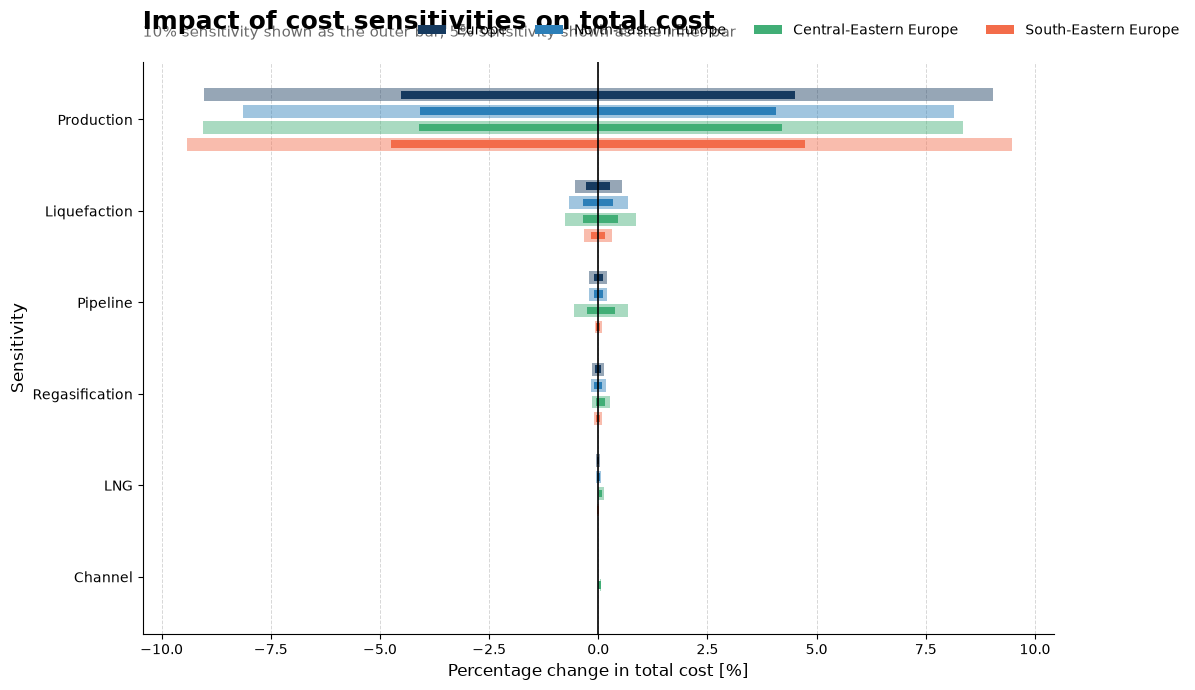

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# TORNADO PLOT: REGIONAL SENSITIVITY
# ============================================================

# Regions to include
regions_to_plot = [
    "Europe",
    "North-Eastern Europe",
    "Central-Eastern Europe",
    "South-Eastern Europe",
]


# Sensitivity types
sensitivity_types = [
    "prod",
    "liqu",
    "pipe",
    "regas",
    "lng",
    "channel",
]


# ============================================================
# REGION COLOURS
# ============================================================

# Same four colours throughout the plot
region_colors = {
    "Europe": "#163A5F",
    "North-Eastern Europe": "#2C7FB8",
    "Central-Eastern Europe": "#41AE76",
    "South-Eastern Europe": "#F36C4A",
}


# ============================================================
# PREPARE DATA
# ============================================================

plot_df = regional_results[
    regional_results["Node"].isin(regions_to_plot)
].copy()

plot_df = plot_df.set_index("Node")


# ============================================================
# CALCULATE ONE RANGE PER SENSITIVITY
#
# 10% sensitivity = outer bar
# 5% sensitivity  = inner bar
#
# For each sensitivity:
#
#     10pdown <----- 0 -----> 10pup
#       5pdown <--- 0 ---> 5pup
#
# The 5% range is plotted on top of the 10% range.
# ============================================================

sensitivity_data = {}

for sensitivity in sensitivity_types:

    sensitivity_data[sensitivity] = {}

    for region in regions_to_plot:

        # 10% changes
        value_10pup = plot_df.loc[
            region,
            f"{sensitivity}_10pup"
        ]

        value_10pdown = plot_df.loc[
            region,
            f"{sensitivity}_10pdown"
        ]

        # 5% changes
        value_05pup = plot_df.loc[
            region,
            f"{sensitivity}_05pup"
        ]

        value_05pdown = plot_df.loc[
            region,
            f"{sensitivity}_05pdown"
        ]

        sensitivity_data[
            sensitivity
        ][region] = {
            "10pup": value_10pup,
            "10pdown": value_10pdown,
            "05pup": value_05pup,
            "05pdown": value_05pdown,
        }


# ============================================================
# ORDER SENSITIVITIES
#
# Order according to the largest absolute 10% effect
# across all four regions.
# ============================================================

sensitivity_order = []

for sensitivity in sensitivity_types:

    max_effect = 0

    for region in regions_to_plot:

        values = sensitivity_data[
            sensitivity
        ][region]

        max_effect = max(
            max_effect,
            abs(values["10pup"]),
            abs(values["10pdown"])
        )

    sensitivity_order.append(
        (
            sensitivity,
            max_effect
        )
    )


sensitivity_order = [
    x[0]
    for x in sorted(
        sensitivity_order,
        key=lambda x: x[1],
        reverse=True
    )
]


# ============================================================
# LABELS
# ============================================================

sensitivity_labels = {
    "prod": "Production",
    "liqu": "Liquefaction",
    "pipe": "Pipeline",
    "regas": "Regasification",
    "lng": "LNG",
    "channel": "Channel",
}


y_labels = [
    sensitivity_labels[s]
    for s in sensitivity_order
]


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)


# ============================================================
# BAR POSITIONS
# ============================================================

n_sensitivities = len(
    sensitivity_order
)

n_regions = len(
    regions_to_plot
)

# Overall height available for each sensitivity
group_height = 0.82

# Small offsets for the four regions
region_offsets = np.linspace(
    -0.27,
    0.27,
    n_regions
)

# Height of each regional bar
bar_height = 0.14

y_positions = np.arange(
    n_sensitivities
)


# ============================================================
# PLOT BARS
# ============================================================

for sensitivity_index, sensitivity in enumerate(
    sensitivity_order
):

    y_base = y_positions[
        sensitivity_index
    ]

    for region_index, region in enumerate(
        regions_to_plot
    ):

        values = sensitivity_data[
            sensitivity
        ][region]

        y = (
            y_base
            + region_offsets[region_index]
        )

        color = region_colors[
            region
        ]


        # ----------------------------------------------------
        # 10% sensitivity - OUTER BAR
        # ----------------------------------------------------

        low_10 = values["10pdown"]
        high_10 = values["10pup"]

        left_10 = min(
            low_10,
            high_10
        )

        width_10 = abs(
            high_10 - low_10
        )

        ax.barh(
            y,
            width_10,
            left=left_10,
            height=bar_height,
            color=color,
            alpha=0.45,
            edgecolor="none",
            zorder=2
        )


        # ----------------------------------------------------
        # 5% sensitivity - INNER BAR
        # ----------------------------------------------------

        low_05 = values["05pdown"]
        high_05 = values["05pup"]

        left_05 = min(
            low_05,
            high_05
        )

        width_05 = abs(
            high_05 - low_05
        )

        ax.barh(
            y,
            width_05,
            left=left_05,
            height=bar_height * 0.60,
            color=color,
            alpha=1.0,
            edgecolor="none",
            zorder=3
        )


# ============================================================
# ZERO LINE
# ============================================================

ax.axvline(
    0,
    linewidth=1.2,
    color="black",
    zorder=4
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    y_labels
)

ax.set_xlabel(
    "Percentage change in total cost [%]",
    fontsize=12
)

ax.set_ylabel(
    "Sensitivity",
    fontsize=12
)


# ============================================================
# TITLE / SUBTITLE
# ============================================================

ax.set_title(
    "Impact of cost sensitivities on total cost",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=24
)

ax.text(
    0,
    1.045,
    "10% sensitivity shown as the outer bar; 5% sensitivity shown as the inner bar",
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray",
    ha="left"
)


# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5,
    zorder=1
)

ax.set_axisbelow(
    True
)


# ============================================================
# REGION LEGEND
# ============================================================

legend_handles = [
    Patch(
        facecolor=region_colors[region],
        label=region
    )
    for region in regions_to_plot
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.72, 1.09),
    ncol=4,
    frameon=False,
    fontsize=10
)


# ============================================================
# FORMAT
# ============================================================

# Put largest sensitivity at the top
ax.invert_yaxis()

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep left/bottom axis
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Tick formatting
ax.tick_params(
    axis="both",
    labelsize=10
)

# Slightly extend x-axis beyond largest value
all_values = []

for sensitivity in sensitivity_types:

    for region in regions_to_plot:

        values = sensitivity_data[
            sensitivity
        ][region]

        all_values.extend([
            values["10pup"],
            values["10pdown"],
        ])

x_max = max(
    abs(min(all_values)),
    abs(max(all_values))
)

ax.set_xlim(
    -x_max * 1.10,
    x_max * 1.10
)


plt.tight_layout()

plt.show()